## Практика 1. Структура датасета, базовые графики

Хотя не требуется первой практикой, дополнительные графики и выводы сделала из собственного интереса. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
df = pd.read_csv("Titanic-Dataset.csv",  index_col="PassengerId")

df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [5]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [6]:
df.dtypes

Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Cabin        object
Embarked     object
dtype: object

### Выводы по структуре датасета:

Датасет содержит 891 запись и 11 переменных. 

**Целевая переменная - `Survived`.**
- Она отображает выжил определенный пассажир (значение 1) или же нет (значение 0). Среднее значение `0.384` показывает, что выжило только 38.4% пассажиров. 

**В датасете присутствуют, как числовые, так и категориальные переменные.**
- Числовые: `Age`, `Fare`, `SibSp`, `Parch`.
- Категориальные: `Sex`, `Embarked`, `Cabin`, `Ticket`, `Name`. `Pclass` и `Survived` также являются категориальными переменными, но отображены они численно.

**Есть пропущенные значения**
- В колонке `Age` отсутствует 177 значений - 19.86%
- В колонке `Cabin` отсутствует 687 значений - 77.1%

**Возраст пассажиров сильно варьируется**
- Минимальный возраст - `0.42`, максимальный - `80`. Средний возраст около 29 лет. 


## Графики

### Bar Chart

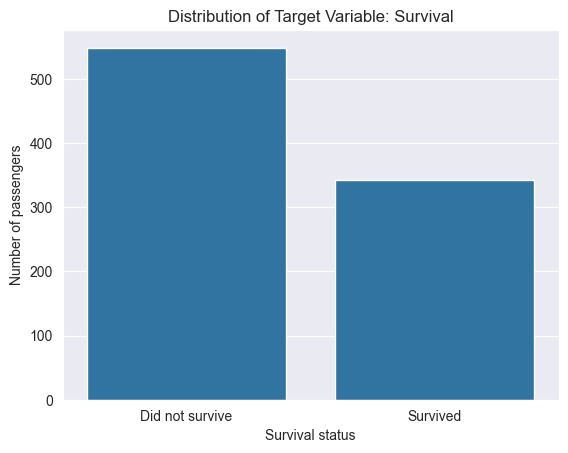

In [31]:
target_df = df.copy()

target_df["SurvivedLabel"] = target_df["Survived"].map({
    0: "Did not survive",
    1: "Survived"
})

sns.countplot(data=target_df, x="SurvivedLabel")

plt.title("Distribution of Target Variable: Survival")
plt.xlabel("Survival status")
plt.ylabel("Number of passengers")

plt.show()

Вывод: 

График показывает распределение целевой переменной — выживаемости пассажиров. Видно, что невыживших пассажиров было больше, чем выживших: примерно 550 против 340. Классы несбалансированы. 

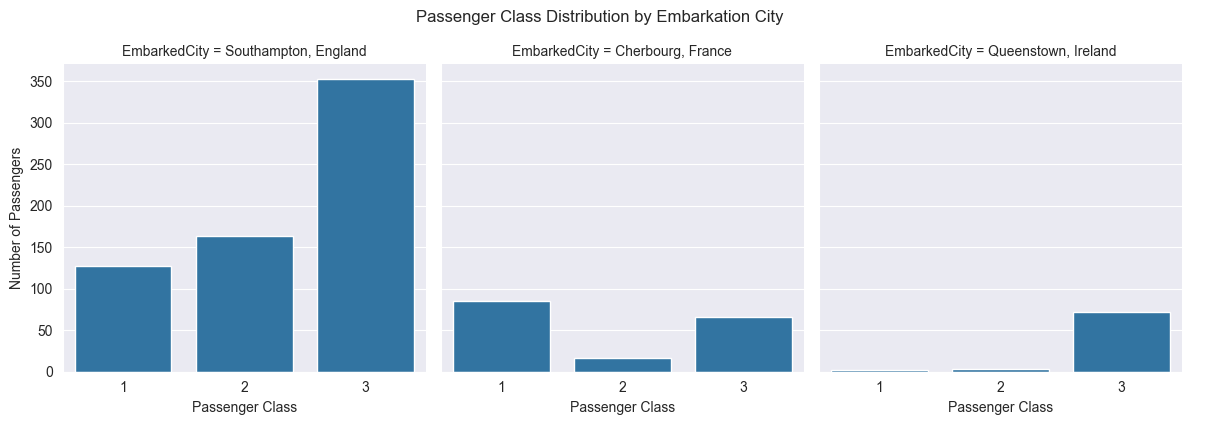

In [18]:
embarked_df = df.copy()
embarked_df["EmbarkedCity"] = embarked_df["Embarked"].map(
    {'C': "Cherbourg, France", 
     'Q': "Queenstown, Ireland",
     'S': 'Southampton, England'})

g = sns.catplot(
    data=embarked_df,
    x="Pclass",
    col="EmbarkedCity",
    kind="count",
    height=4,
    aspect=1
)

g.fig.suptitle("Passenger Class Distribution by Embarkation City", y=1.05)
g.set_axis_labels("Passenger Class", "Number of Passengers")

plt.show()

Вывод:

В качестве дополнительного анализа было интересно посмотреть, как распределялись пассажиры разных классов в зависимости от города посадки.

График показывает, что распределение пассажиров по классам сильно различалось в зависимости от города посадки. В Southamption село наиболее большое количество пассажиров, большинство из них были пассажирами третьего класса. В Cherbourg, наоборот, заметно больше пассажиров первого класса по сравнению со вторым и третьим классом. В Queenstown пассажиров было значительно меньше, и почти все они относились к третьему классу.

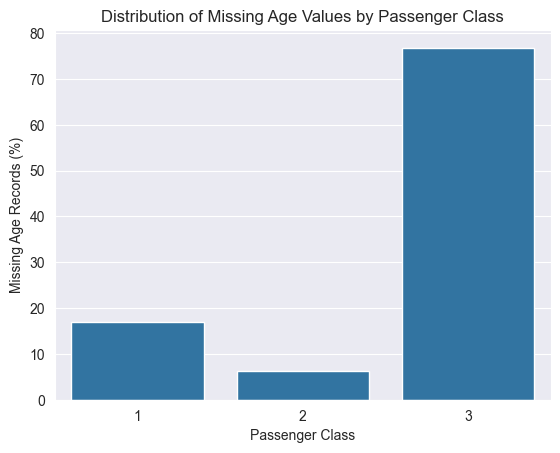

In [9]:
df_nill_age = df[df['Age'].isnull()]
sns.countplot(data=df_nill_age, x="Pclass", stat='percent')

plt.title('Distribution of Missing Age Values by Passenger Class')
plt.xlabel("Passenger Class")
plt.ylabel("Missing Age Records (%)")
plt.show()

In [23]:
for pclass in [1, 2, 3]:
    class_nil = df_nill_age[df_nill_age["Pclass"] == pclass]
    total_num_class = len(df[df["Pclass"] == pclass])
    
    percentage = len(class_nil) / total_num_class * 100
    
    print(
        f"Out of {total_num_class} class {pclass} passengers, "
        f"{len(class_nil)} do not have a specified age: {percentage:.2f}%"
    )


Out of 216 class 1 passengers, 30 do not have a specified age: 13.89%
Out of 184 class 2 passengers, 11 do not have a specified age: 5.98%
Out of 491 class 3 passengers, 136 do not have a specified age: 27.70%


Вывод:

Этот график сделала из интереса, чтобы попытаться объяснить пропущенные значения в колонке `Age`. Можно увидеть, что из 177 пропущенных значений, около 76% из них принадлежат пассажирам третьего класса, около 17% пассажирам первого класса, а оставшиеся 7% пассажирам второго класса. 

Дополнительный расчет показывает, что внутри самих классов доля пропущенных возрастов также различается: в третьем классе возраст не указан у 27.70% пассажиров, в первом классе — у 13.89%, а во втором классе — только у 5.98%.

Таким образом, пропущенные значения чаще всего встречаются у пассаэиров третьего класса. Это может быть связано как с тем, что третий класс был самым многочисленным, так и с тем, что данные о пассажирах этого класса могли быть собраны менее полно / менее аккуратно

### Line Chart

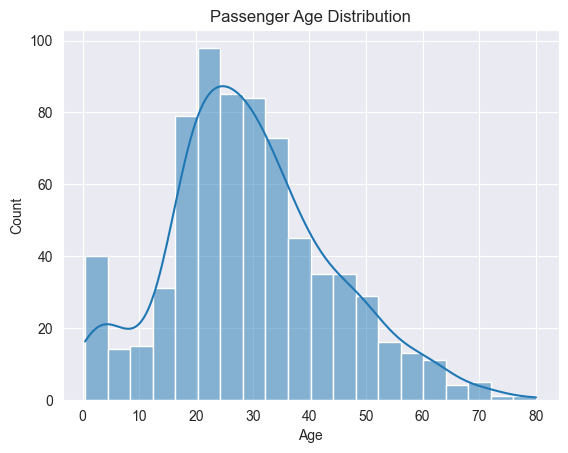

In [10]:
sns.histplot(data=df['Age'], kde=True)

plt.title('Passenger Age Distribution')
plt.show()

In [27]:
df['Age'].median()

np.float64(28.0)

Вывод:

Распределение слегка скошено вправо. Скорее всего из-за того, что большинство пассажиров находятся в возрастном диапазоне примерно от 18 до 38 лет, но при этом есть более старшие пассажиры, которые формируют правый хвост. Медианное значение составляет 28 лет. Из интересного, достаточно много маленьких детей (возраст < 5 лет).

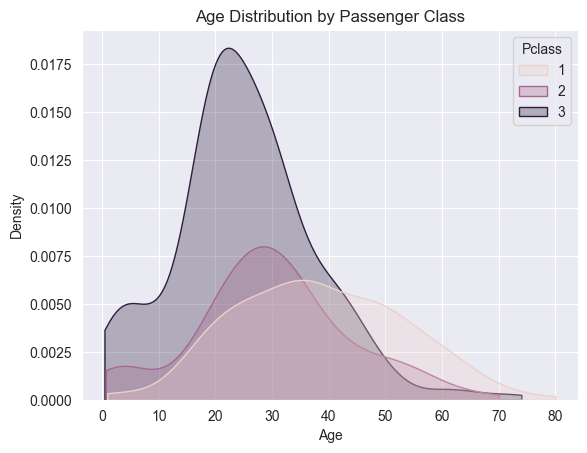

In [11]:
ax = sns.kdeplot(data=df, x='Age', hue='Pclass', fill=True, cut=0, alpha=0.3)

plt.title('Age Distribution by Passenger Class')
plt.show()

In [41]:
first_class = df[df['Pclass'] == 1]
second_class = df[df['Pclass'] == 2]
third_class = df[df['Pclass'] == 3]

print("First class:", first_class['Age'].skew())
print("Second class:", second_class['Age'].skew())
print("Third class:", third_class['Age'].skew())

First class: 0.11985744501915112
Second class: 0.13383744196510058
Third class: 0.48398975232858193


Вывод:

На этом графике можно чуть детальнее посмотреть, как распределение возраста меняется в зависимости от класса. Видно, что пассажиры третьего класса, в среднем, были самыми молодыми - большинству было от 20 до 25 лет. Пассажирам во втором классе было примерно 25-35 лет. 

Распределение возраста в первом классе выглядит, сравнительно, наиболее симметрично. Основная часть пассажиров была от 30 до 50 лет. При этом, заметно, что самые пожилые пассажиры были именно в этом классе.

### Scatter Plot

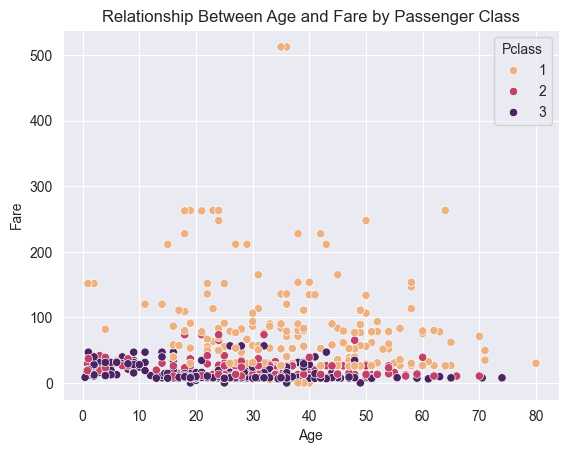

In [12]:
sns.scatterplot(data=df, x='Age', y='Fare', hue='Pclass',  palette='flare')

plt.title('Relationship Between Age and Fare by Passenger Class')
plt.show()

Вывод:

На графике видно, что стоимость билета сильнее связана с классом пассажира, чем с возрастом. Билеты первого класса в среднем заметно дороже, а также имеют самый большой разброс значений: среди них встречаются как относительно недорогие билеты, так и очень дорогие.

Во втором и третьем классах цены в основном сконцентрированы в нижней части графика, то есть билеты были дешевле и более однотипны по стоимости. При этом явной зависимости между возрастом и ценой билета не наблюдается: пассажиры разных возрастов могли иметь как дешёвые, так и дорогие билеты.


### Line Chart

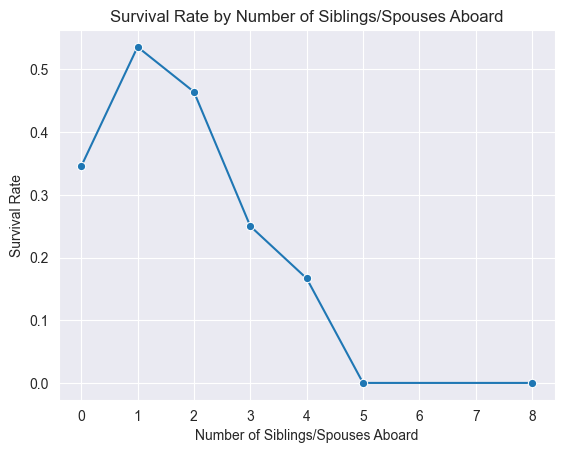

In [13]:
survival_by_sibsp = df.groupby("SibSp")["Survived"].mean().reset_index()

ax = sns.lineplot(
    data=survival_by_sibsp,
    x="SibSp",
    y="Survived",
    marker="o"
)

ax.set_title("Survival Rate by Number of Siblings/Spouses Aboard")
ax.set_xlabel("Number of Siblings/Spouses Aboard")
ax.set_ylabel("Survival Rate")

plt.show()

In [37]:
corr_pearson = df['SibSp'].corr(df['Survived'])
corr_spearman = df['SibSp'].corr(df['Survived'], method='spearman')

print(f"Pearson correlation: {corr_pearson:.3f}")
print(f"Spearman correlation: {corr_spearman:.3f}")

Pearson correlation: -0.035
Spearman correlation: 0.089


In [40]:
print(len(df[df['SibSp'] >= 5]))

12


Вывод:

График показывает, что самая высокая выживаемость была у пассажиров с 1–2 родственниками на борту. После этого выживаемость постепенно снижается, а у пассажиров с 5 и 8 родственниками она равна 0.

Корреляция очень слабая: Pearson = -0.035, Spearman = 0.089.

### Heatmap

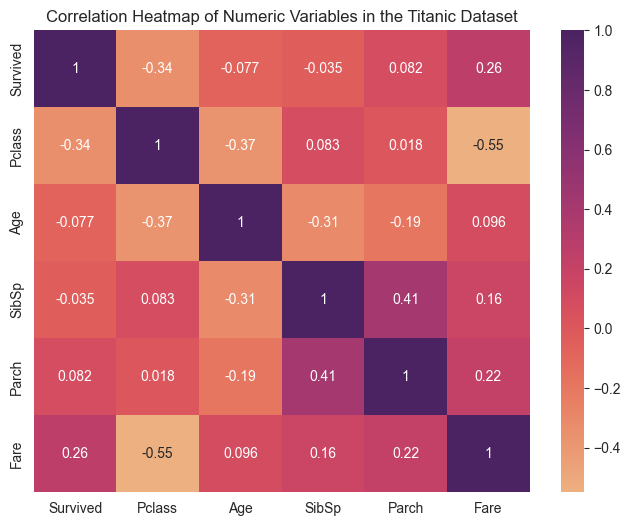

In [14]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap='flare')

plt.title("Correlation Heatmap of Numeric Variables in the Titanic Dataset")
plt.show()

Вывод:

В целом, heatmap показывает, что сильных корреляций между переменными нет. 

Есть несколько умеренно или слабо негативных: Pclass x Fare (-0.55), Pclass x Age (-0.37), Survived x Pclass (-0.34). 

Есть одна умеренно позитивная: SibSp x Parch (0.41) - связь между количеством братьев/сестер или супругов и количеством родителей/детей на борту. 

### Box Plot

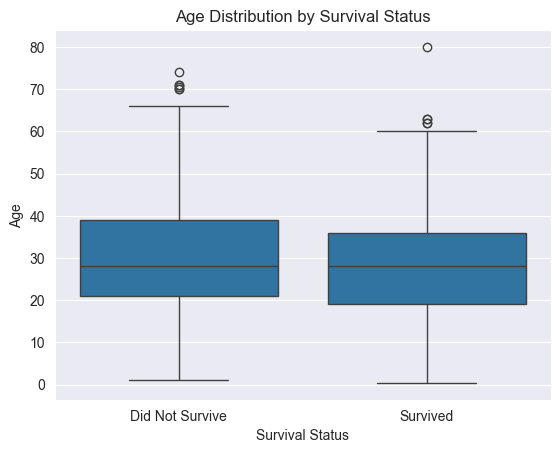

In [15]:
df_plot = df.copy()
df_plot["Survived"] = df_plot["Survived"].map({0: "Did Not Survive", 1: "Survived"})

sns.boxplot(data=df_plot, x="Survived", y="Age")

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Age")
plt.show()

Вывод:

График показывает, что распределение возраста у выживших и невыживших пассажиров довольно похожее. Медианный возраст в обеих группах примерно одинаковый — около 28 лет.